In [15]:
# ===============================
# 1. Importar librerías
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# 2. Crear datos aleatorios
# ===============================
np.random.seed(42) # para reproducibilidad

# Nombres ficticios (se repiten aleatoriamente)
nombres = np.random.choice(
["Ana", "Luis", "Marta", "Juan", "Sofía", "Pedro", "Laura", "Andrés"],
size=100
)

# Edades entre 18 y 50 años, con algunos valores faltantes
edades = np.random.randint(18, 50, size=100).astype(float)
edades[np.random.choice(100, 5, replace=False)] = np.nan # 5 valores nulos

# Ciudades
ciudades = np.random.choice(["Medellín", "Bogotá", "Cali"], size=100)

# Notas entre 2.0 y 5.0
notas = np.round(np.random.uniform(2.0, 5.0, size=100), 1)

# ===============================
# 3. Crear DataFrame
# ===============================
df = pd.DataFrame({
"Nombre": nombres,
"Edad": edades,
"Ciudad": ciudades,
"Nota": notas
})

print(" Primeras filas del Data Frame inicial:")
print(df.head())


 Primeras filas del Data Frame inicial:
  Nombre  Edad    Ciudad  Nota
0  Laura  48.0  Medellín   2.9
1   Juan  35.0  Medellín   2.6
2  Sofía  43.0      Cali   2.8
3  Laura  29.0    Bogotá   3.5
4  Marta  19.0  Medellín   3.1


In [16]:
print("Información general del DataFrame:\n")
df.info()

print("\nCantidad de valores faltantes por columna:\n")
print(df.isnull().sum())

Información general del DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nombre  100 non-null    object 
 1   Edad    95 non-null     float64
 2   Ciudad  100 non-null    object 
 3   Nota    100 non-null    float64
dtypes: float64(2), object(2)
memory usage: 3.3+ KB

Cantidad de valores faltantes por columna:

Nombre    0
Edad      5
Ciudad    0
Nota      0
dtype: int64


In [17]:
print("Estadísticas descriptivas de las columnas numéricas:\n")
print(df.describe())

Estadísticas descriptivas de las columnas numéricas:

            Edad        Nota
count  95.000000  100.000000
mean   32.400000    3.295000
std     9.327835    0.887213
min    18.000000    2.000000
25%    25.000000    2.575000
50%    32.000000    3.150000
75%    41.000000    4.025000
max    48.000000    4.900000


In [18]:
print("Frecuencia de valores para la columna 'Nombre':\n")
print(df['Nombre'].value_counts())

print("\nFrecuencia de valores para la columna 'Ciudad':\n")
print(df['Ciudad'].value_counts())

Frecuencia de valores para la columna 'Nombre':

Nombre
Juan      19
Laura     13
Pedro     13
Luis      13
Sofía     12
Marta     11
Andrés    11
Ana        8
Name: count, dtype: int64

Frecuencia de valores para la columna 'Ciudad':

Ciudad
Medellín    40
Cali        30
Bogotá      30
Name: count, dtype: int64


In [19]:
median_edad = df['Edad'].median()
print(f"Mediana de la columna 'Edad': {median_edad:.2f}")

df['Edad'].fillna(median_edad, inplace=True)

print("\nCantidad de valores faltantes en 'Edad' después de la imputación:")
print(df['Edad'].isnull().sum())

Mediana de la columna 'Edad': 32.00

Cantidad de valores faltantes en 'Edad' después de la imputación:
0


/tmp/ipython-input-513977143.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Edad'].fillna(median_edad, inplace=True)


In [20]:
median_edad = df['Edad'].median()
print(f"Mediana de la columna 'Edad': {median_edad:.2f}")

df['Edad'] = df['Edad'].fillna(median_edad)

print("\nCantidad de valores faltantes en 'Edad' después de la imputación:")
print(df['Edad'].isnull().sum())

Mediana de la columna 'Edad': 32.00

Cantidad de valores faltantes en 'Edad' después de la imputación:
0


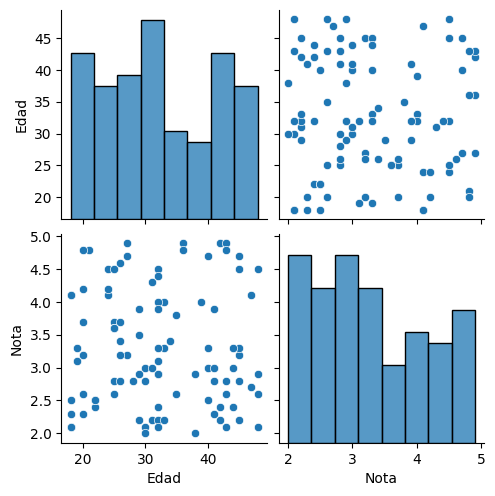

In [21]:
import seaborn as sns
sns.pairplot(df)
plt.show()

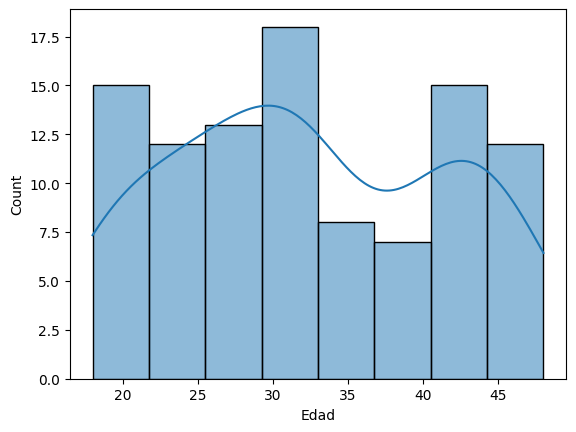

In [22]:
sns.histplot(df['Edad'], kde=True)
plt.show()

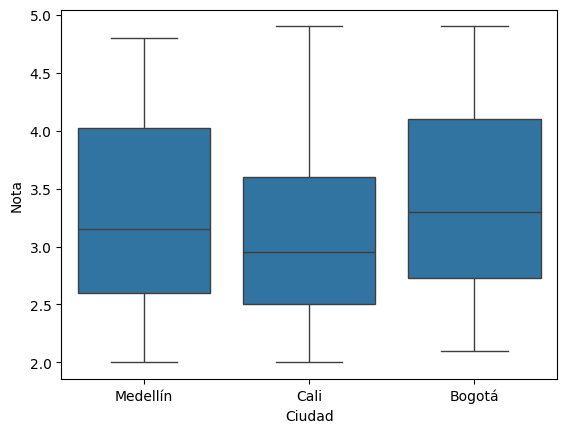

In [23]:
sns.boxplot(x='Ciudad', y='Nota', data=df)
plt.show()

In [24]:
df = pd.get_dummies(df, columns=['Ciudad'], drop_first=True)
print(df.head())

  Nombre  Edad  Nota  Ciudad_Cali  Ciudad_Medellín
0  Laura  48.0   2.9        False             True
1   Juan  35.0   2.6        False             True
2  Sofía  43.0   2.8         True            False
3  Laura  29.0   3.5        False            False
4  Marta  19.0   3.1        False             True
